In [10]:
%load_ext autoreload
%autoreload 2


import json
import os

from pydantic import BaseModel, Field

from openweights import Jobs, OpenWeights, register
from genbench import Experiment, Alias


ow = OpenWeights()


class ExampleParams(BaseModel):
    """Parameters for our addition job"""
    a: float = Field(..., description="First number to add")
    b: float = Field(..., description="Second number to add")
    max_iter: float = Field(..., description="max iter")


@register("example")  # After registering it, we can use it as ow.addition
class ExampleJob(Jobs):
    # Mount our addition script
    mount = {
        "custom_job/worker_side.py": "worker_side.py"
    }

    # Define parameter validation using our Pydantic model
    params = ExampleParams

    requires_vram_gb = 0

    def get_entrypoint(self, validated_params: ExampleParams) -> str:
        """Create the command to run our script with the validated parameters"""
        # Convert parameters to JSON string to pass to script
        params_json = json.dumps(validated_params.model_dump())
        return f"python worker_side.py '{params_json}'"




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Connected to org:  niels


In [11]:
experiment = Experiment(
    base_job=ExampleJob(ow),
    params=dict(
        a=0.1,
        max_iter=100
    )
)

for b in [-1, -0.5, 0, 0.5, 1]:
    experiment.run(
        b=Alias(value=b, name=f'Imaginary({b})'),
    )


experiment.jobs().list()


[Job(id='examplejob-dae23acb29bd', type='custom', status='in_progress', model=None, requires_vram_gb=0, docker_image='nielsrolf/ow-default:v0.6', script='python worker_side.py \'{"a": 0.1, "b": -1.0, "max_iter": 100.0}\'', params={'mounted_files': {'worker_side.py': 'custom_job_file:file-45e94822e2e9'}, 'validated_params': {'a': 0.1, 'b': -1.0, 'max_iter': 100.0}}, outputs=None, organization_id='2270c441-9b13-4c5c-a006-c8642026c17f', created_at='2025-10-06T08:58:07.186283+00:00', updated_at='2025-10-06T08:58:07.33947+00:00', worker_id='2270c441-9b13-4c5c-a006-c8642026c17f-8612235f', timeout=None, allowed_hardware=None, _manager=<openweights.client.jobs.Jobs object at 0x120fcf510>),
 Job(id='examplejob-600112b7febe', type='custom', status='in_progress', model=None, requires_vram_gb=0, docker_image='nielsrolf/ow-default:v0.6', script='python worker_side.py \'{"a": 0.1, "b": -0.5, "max_iter": 100.0}\'', params={'mounted_files': {'worker_side.py': 'custom_job_file:file-45e94822e2e9'}, 'val

In [17]:
experiment.jobs().dict(groupby='b') # List[Job]

defaultdict(list,
            {'Imaginary(-1)': [Job(id='examplejob-dae23acb29bd', type='custom', status='completed', model=None, requires_vram_gb=0, docker_image='nielsrolf/ow-default:v0.6', script='python worker_side.py \'{"a": 0.1, "b": -1.0, "max_iter": 100.0}\'', params={'mounted_files': {'worker_side.py': 'custom_job_file:file-45e94822e2e9'}, 'validated_params': {'a': 0.1, 'b': -1.0, 'max_iter': 100.0}}, outputs={'imag': -2.2448288, 'real': -0.8903015900000004, 'step': 3}, organization_id='2270c441-9b13-4c5c-a006-c8642026c17f', created_at='2025-10-06T08:58:07.186283+00:00', updated_at='2025-10-06T08:58:15.311025+00:00', worker_id='2270c441-9b13-4c5c-a006-c8642026c17f-8612235f', timeout=None, allowed_hardware=None, _manager=<openweights.client.jobs.Jobs object at 0x120fcf510>)],
             'Imaginary(-0.5)': [Job(id='examplejob-600112b7febe', type='custom', status='completed', model=None, requires_vram_gb=0, docker_image='nielsrolf/ow-default:v0.6', script='python worker_side.py

In [16]:
experiment.jobs().df

,b,value
0,Imaginary(-1),"Job(id='examplejob-dae23acb29bd', type='custom..."
1,Imaginary(-0.5),"Job(id='examplejob-600112b7febe', type='custom..."
2,Imaginary(0),"Job(id='examplejob-5b47c739b410', type='custom..."
3,Imaginary(0.5),"Job(id='examplejob-ccfdd24071e8', type='custom..."
4,Imaginary(1),"Job(id='examplejob-63a572c85044', type='custom..."


In [9]:
experiment.retry_failed()

In [10]:
experiment.cancel()

In [8]:
experiment.save('example.json')

Experiment.load('example.json', ExampleJob(ow)).jobs().df

,b,value
0,Imaginary(-1),"Job(id='examplejob-3003e91db143', type='custom..."
1,Imaginary(-0.5),"Job(id='examplejob-56404d075ad8', type='custom..."
2,Imaginary(0),"Job(id='examplejob-f217a52431f6', type='custom..."
3,Imaginary(0.5),"Job(id='examplejob-f660ad36dff9', type='custom..."
4,Imaginary(1),"Job(id='examplejob-067e431c6729', type='custom..."


In [19]:
df = experiment.get_metrics_df()
df

examplejob-dae23acb29bd {'b': 'Imaginary(-1)'}
examplejob-600112b7febe {'b': 'Imaginary(-0.5)'}
examplejob-5b47c739b410 {'b': 'Imaginary(0)'}
examplejob-ccfdd24071e8 {'b': 'Imaginary(0.5)'}
examplejob-63a572c85044 {'b': 'Imaginary(1)'}


,imag,real,step,b
0,-1.000000,0.100000,0,Imaginary(-1)
1,-1.200000,-0.890000,1,Imaginary(-1)
2,1.136000,-0.547900,2,Imaginary(-1)
3,-2.244829,-0.890302,3,Imaginary(-1)
0,-0.500000,0.100000,0,Imaginary(-0.5)
...,...,...,...,...
99,0.431286,-0.079662,99,Imaginary(0.5)
0,1.000000,0.100000,0,Imaginary(1)
1,1.200000,-0.890000,1,Imaginary(1)
2,-1.136000,-0.547900,2,Imaginary(1)


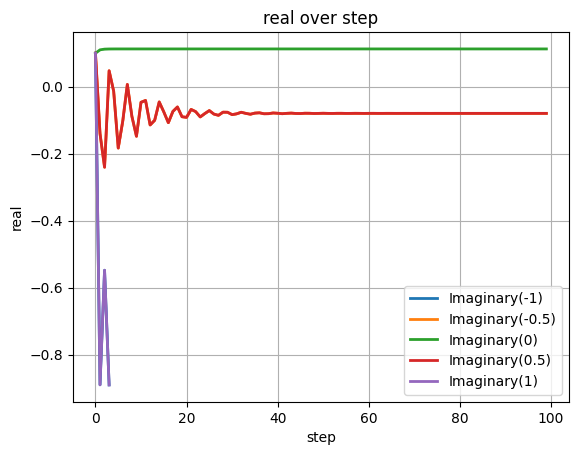

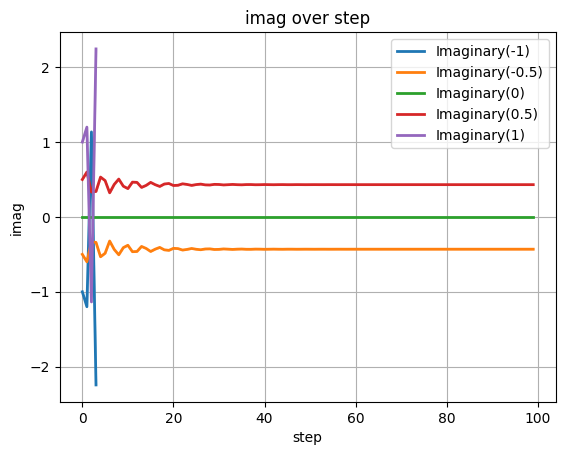

In [25]:
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import seaborn as sns

def plot_metrics(df_events, x='step', y=None, color='tag', minimal=False, ax=None):
    """
    Plot metric 'y' over 'x' from df_events, grouped and colored by 'color'.

    Parameters
    ----------
    df_events : pd.DataFrame
        Must contain columns specified in x, y, and color.
    x : str, optional
        Column name for the x-axis (default: 'step').
    y : str, required
        Column name for the y-axis (metric to plot).
    color : str, optional
        Column name used for grouping and coloring lines/fills (default: 'tag').
    minimal : bool, optional
        If True, suppresses legend, labels, and titles.
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. Creates one if None.
    """
    if y is None:
        raise ValueError("You must specify a 'y' column to plot.")

    if ax is None:
        fig, ax = plt.subplots()

    if not is_numeric_dtype(df_events[y]):
        raise ValueError(f"Column '{y}' must be numeric.")

    df_metric = df_events.dropna(subset=[x, color, y])
    unique_groups = df_metric[color].unique()

    # consistent color palette
    palette = dict(zip(unique_groups, sns.color_palette("tab10", len(unique_groups))))

    for key in unique_groups:
        df_tmp = df_metric[df_metric[color] == key]
        if len(df_tmp) > 1:
            grouped = df_tmp.groupby(x)[y].agg(["mean", "min", "max"])
            c = palette[key]
            ax.plot(grouped.index, grouped["mean"], label=f"{key}", color=c, linewidth=2)
            ax.fill_between(grouped.index, grouped["min"], grouped["max"], color=c, alpha=0.2)

    if not minimal:
        if len(unique_groups) > 1:
            ax.legend()
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{y} over {x}")
        ax.grid(True)

    return ax




plot_metrics(
    df,
    x='step',
    y='real',
    color='b'
)
plt.show()

plot_metrics(
    df,
    x='step',
    y='imag',
    color='b'
)
plt.show()




In [26]:
experiment.models().dict(groupby='b') # List[Job]

defaultdict(list, {})

In [ ]:
from vibes_eval import FreeformEval

main_eval = FreeformEval.from_yaml('emergent_misalignment.yaml')

models = experiment.models().dict(groupby='b') 


# Run eval for all models
results = await main_eval.run(models)
results.df.to_csv("results.csv", index=False)
results.scatter(          # Compare two metrics
    x_column="coherent",
    y_column="aligned",
    alpha=0.7
).savefig("scatter.png")
